In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


In [50]:
##READING COMPLAINT DATA
Complaint = pd.read_csv("https://data.cityofnewyork.us/resource/5uac-w243.csv?$limit=50000")
Complaint

/tmp/ipykernel_36072/2542949993.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  Complaint = pd.read_csv("https://data.cityofnewyork.us/resource/5uac-w243.csv?$limit=50000")


,cmplnt_num,addr_pct_cd,boro_nm,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,crm_atpt_cptd_cd,hadevelopt,housing_psa,...,transit_district,vic_age_group,vic_race,vic_sex,x_coord_cd,y_coord_cd,latitude,longitude,lat_lon,geocoded_column
0,298784667,114,QUEENS,2024-12-09T00:00:00.000,04:37:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1016307,227998,40.792430,-73.884228,"(40.79243, -73.884228)",POINT (-73.884228 40.79243)
1,308328240,41,BRONX,2025-06-18T00:00:00.000,16:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1017940,232184,40.803914,-73.878308,"(40.803914, -73.878308)",POINT (-73.878308 40.803914)
2,314788366,40,BRONX,2025-10-17T00:00:00.000,22:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,BLACK HISPANIC,F,1005028,234516,40.810352,-73.924942,"(40.8103518634571, -73.924942325642)",POINT (-73.924942325642 40.8103518634571)
3,307568863,41,BRONX,2025-03-24T00:00:00.000,01:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,WHITE,F,1013037,236657,40.816206,-73.896001,"(40.8162058439227, -73.8960011932583)",POINT (-73.8960011932583 40.8162058439227)
4,311408135H1,42,BRONX,2025-08-18T00:00:00.000,22:34:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,25-44,BLACK,M,1009748,240283,40.826169,-73.907868,"(40.826169, -73.907868)",POINT (-73.907868 40.826169)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,299696002,120,STATEN ISLAND,2025-01-19T00:00:00.000,12:15:00,2025-01-19T00:00:00.000,12:22:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,962387,167289,40.625827,-74.078761,"(40.625827, -74.078761)",POINT (-74.078761 40.625827)
49996,304335809,66,BROOKLYN,2025-04-04T00:00:00.000,19:30:00,2025-04-04T00:00:00.000,19:35:00,COMPLETED,(null),NaN,...,NaN,45-64,WHITE,M,991231,166952,40.624927,-73.974852,"(40.624927, -73.974852)",POINT (-73.974852 40.624927)
49997,311388184,70,BROOKLYN,2025-08-18T00:00:00.000,15:05:00,2025-08-18T00:00:00.000,15:10:00,COMPLETED,(null),NaN,...,34.0,UNKNOWN,UNKNOWN,D,994973,168826,40.630058,-73.961369,"(40.63005838, -73.96136854)",POINT (-73.96136854 40.63005838)
49998,302446874,121,STATEN ISLAND,2025-03-12T00:00:00.000,02:15:00,2025-03-12T00:00:00.000,02:30:00,COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,942822,166353,40.623188,-74.149238,"(40.6231883776008, -74.1492376947323)",POINT (-74.1492376947323 40.6231883776008)


In [51]:
Complaint.columns

Index(['cmplnt_num', 'addr_pct_cd', 'boro_nm', 'cmplnt_fr_dt', 'cmplnt_fr_tm',
       'cmplnt_to_dt', 'cmplnt_to_tm', 'crm_atpt_cptd_cd', 'hadevelopt',
       'housing_psa', 'jurisdiction_code', 'juris_desc', 'ky_cd', 'law_cat_cd',
       'loc_of_occur_desc', 'ofns_desc', 'parks_nm', 'patrol_boro', 'pd_cd',
       'pd_desc', 'prem_typ_desc', 'rpt_dt', 'station_name', 'susp_age_group',
       'susp_race', 'susp_sex', 'transit_district', 'vic_age_group',
       'vic_race', 'vic_sex', 'x_coord_cd', 'y_coord_cd', 'latitude',
       'longitude', 'lat_lon', 'geocoded_column'],
      dtype='object')

In [52]:
###READING ARREST DATA
Arrest = pd.read_csv(
    "https://data.cityofnewyork.us/resource/uip8-fykc.csv?$limit=50000")

In [53]:
Arrest.columns

Index(['arrest_key', 'arrest_date', 'pd_cd', 'pd_desc', 'ky_cd', 'ofns_desc',
       'law_code', 'law_cat_cd', 'arrest_boro', 'arrest_precinct',
       'jurisdiction_code', 'age_group', 'perp_sex', 'perp_race', 'x_coord_cd',
       'y_coord_cd', 'latitude', 'longitude', 'geocoded_column'],
      dtype='object')

In [54]:
common_cols = set(Arrest.columns).intersection(set(Complaint.columns))
print(common_cols)

{'ky_cd', 'pd_desc', 'longitude', 'latitude', 'geocoded_column', 'pd_cd', 'x_coord_cd', 'ofns_desc', 'jurisdiction_code', 'y_coord_cd', 'law_cat_cd'}


In [55]:
Arrest.columns = Arrest.columns.str.strip().str.upper()
Complaint.columns = Complaint.columns.str.strip().str.upper()

###JOINING THE DATA BY JURISDICTION CODE

In [56]:
Arrest['ARREST_DATE'] = pd.to_datetime(Arrest['ARREST_DATE'])
Complaint['CMPLNT_FR_DT'] = pd.to_datetime(Complaint['CMPLNT_FR_DT'])

In [57]:
#Combined the datasets to see which complain led to arrest
Combined = pd.merge(
    Arrest,
    Complaint,
    left_on=['JURISDICTION_CODE','KY_CD','ARREST_PRECINCT'],
    right_on=['JURISDICTION_CODE','KY_CD','ADDR_PCT_CD'],
    how='inner'
)
Combined.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD_x', 'PD_DESC_x', 'KY_CD',
       'OFNS_DESC_x', 'LAW_CODE', 'LAW_CAT_CD_x', 'ARREST_BORO',
       'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX',
       'PERP_RACE', 'X_COORD_CD_x', 'Y_COORD_CD_x', 'LATITUDE_x',
       'LONGITUDE_x', 'GEOCODED_COLUMN_x', 'CMPLNT_NUM', 'ADDR_PCT_CD',
       'BORO_NM', 'CMPLNT_FR_DT', 'CMPLNT_FR_TM', 'CMPLNT_TO_DT',
       'CMPLNT_TO_TM', 'CRM_ATPT_CPTD_CD', 'HADEVELOPT', 'HOUSING_PSA',
       'JURIS_DESC', 'LAW_CAT_CD_y', 'LOC_OF_OCCUR_DESC', 'OFNS_DESC_y',
       'PARKS_NM', 'PATROL_BORO', 'PD_CD_y', 'PD_DESC_y', 'PREM_TYP_DESC',
       'RPT_DT', 'STATION_NAME', 'SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX',
       'TRANSIT_DISTRICT', 'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX',
       'X_COORD_CD_y', 'Y_COORD_CD_y', 'LATITUDE_y', 'LONGITUDE_y', 'LAT_LON',
       'GEOCODED_COLUMN_y'],
      dtype='object')

In [58]:
Combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523910 entries, 0 to 1523909
Data columns (total 53 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   ARREST_KEY         1523910 non-null  int64         
 1   ARREST_DATE        1523910 non-null  datetime64[ns]
 2   PD_CD_x            1523910 non-null  int64         
 3   PD_DESC_x          1523910 non-null  object        
 4   KY_CD              1523910 non-null  float64       
 5   OFNS_DESC_x        1523910 non-null  object        
 6   LAW_CODE           1523910 non-null  object        
 7   LAW_CAT_CD_x       1523910 non-null  object        
 8   ARREST_BORO        1523910 non-null  object        
 9   ARREST_PRECINCT    1523910 non-null  int64         
 10  JURISDICTION_CODE  1523910 non-null  int64         
 11  AGE_GROUP          1523910 non-null  object        
 12  PERP_SEX           1523910 non-null  object        
 13  PERP_RACE          1523910 

In [59]:
# filter by time window (arrest within 5 years of complaint)
Combined = Combined[
    (Combined['ARREST_DATE'] >= Combined['CMPLNT_FR_DT']) &
    (Combined['ARREST_DATE'] <= Combined['CMPLNT_FR_DT'] + pd.Timedelta(days=1800))
]
Combined

,ARREST_KEY,ARREST_DATE,PD_CD_x,PD_DESC_x,KY_CD,OFNS_DESC_x,LAW_CODE,LAW_CAT_CD_x,ARREST_BORO,ARREST_PRECINCT,...,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD_y,Y_COORD_CD_y,LATITUDE_y,LONGITUDE_y,LAT_LON,GEOCODED_COLUMN_y
38,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,...,NaN,25-44,UNKNOWN,F,965569,160490,40.607176,-74.067278,"(40.607176, -74.067278)",POINT (-74.067278 40.607176)
39,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,...,NaN,25-44,BLACK,M,962610,163009,40.614082,-74.077943,"(40.614082, -74.077943)",POINT (-74.077943 40.614082)
72,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,...,NaN,65+,WHITE HISPANIC,M,964086,161465,40.609846,-74.072623,"(40.609846, -74.072623)",POINT (-74.072623 40.609846)
90,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,...,NaN,25-44,BLACK,M,963772,166550,40.623804,-74.073769,"(40.623804, -74.073769)",POINT (-74.073769 40.623804)
100,304659583,2025-04-12,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,41,...,NaN,18-24,WHITE,F,1013037,236657,40.816206,-73.896001,"(40.8162058439227, -73.8960011932583)",POINT (-73.8960011932583 40.8162058439227)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1523887,303623559,2025-03-25,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,63,...,NaN,25-44,BLACK,M,1007544,165541,40.621028,-73.916090,"(40.621028, -73.91609)",POINT (-73.91609 40.621028)
1523888,303623559,2025-03-25,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,63,...,NaN,<18,BLACK,M,1006768,167074,40.625238,-73.918880,"(40.625238, -73.91888)",POINT (-73.91888 40.625238)
1523889,303623559,2025-03-25,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,63,...,NaN,25-44,BLACK,M,1000371,167386,40.626107,-73.941923,"(40.626107, -73.941923)",POINT (-73.941923 40.626107)
1523892,303623559,2025-03-25,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,F,K,63,...,NaN,18-24,WHITE,F,1001025,165669,40.621392,-73.939574,"(40.621392, -73.939574)",POINT (-73.939574 40.621392)


In [60]:
print(Combined.columns.tolist())

Combined = Combined.rename(columns={
    'BORO_NM': 'borough',
    'SUSP_AGE_GROUP': 'suspect_age',
    'SUSP_RACE': 'suspect_race',
    'SUSP_SEX': 'suspect_sex',
    'VIC_AGE_GROUP': 'victim_age',
    'VIC_RACE': 'victim_race',
    'VIC_SEX': 'victim_sex',
    'LAW_CAT_CD_y': 'offense_category',
    'ADDR_PCT_CD': 'incident_precinct'
})


['ARREST_KEY', 'ARREST_DATE', 'PD_CD_x', 'PD_DESC_x', 'KY_CD', 'OFNS_DESC_x', 'LAW_CODE', 'LAW_CAT_CD_x', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD_x', 'Y_COORD_CD_x', 'LATITUDE_x', 'LONGITUDE_x', 'GEOCODED_COLUMN_x', 'CMPLNT_NUM', 'ADDR_PCT_CD', 'BORO_NM', 'CMPLNT_FR_DT', 'CMPLNT_FR_TM', 'CMPLNT_TO_DT', 'CMPLNT_TO_TM', 'CRM_ATPT_CPTD_CD', 'HADEVELOPT', 'HOUSING_PSA', 'JURIS_DESC', 'LAW_CAT_CD_y', 'LOC_OF_OCCUR_DESC', 'OFNS_DESC_y', 'PARKS_NM', 'PATROL_BORO', 'PD_CD_y', 'PD_DESC_y', 'PREM_TYP_DESC', 'RPT_DT', 'STATION_NAME', 'SUSP_AGE_GROUP', 'SUSP_RACE', 'SUSP_SEX', 'TRANSIT_DISTRICT', 'VIC_AGE_GROUP', 'VIC_RACE', 'VIC_SEX', 'X_COORD_CD_y', 'Y_COORD_CD_y', 'LATITUDE_y', 'LONGITUDE_y', 'LAT_LON', 'GEOCODED_COLUMN_y']


In [61]:
##fILLING MISSING VALUE
Combined[['borough', 'suspect_age', 'suspect_race', 'suspect_sex', 'offense_category']] = \
    Combined[['borough', 'suspect_age', 'suspect_race', 'suspect_sex', 'offense_category']].fillna('missing')

In [64]:

# Make sure of correct types
Combined['ARREST_DATE'] = pd.to_datetime(Combined['ARREST_DATE'], errors='coerce')
Combined = Combined.dropna(subset=['ARREST_DATE'])

Combined['ARREST_PRECINCT'] = pd.to_numeric(Combined['ARREST_PRECINCT'], errors='coerce')
Combined = Combined.dropna(subset=['ARREST_PRECINCT'])
Combined.columns


Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD_x', 'PD_DESC_x', 'KY_CD',
       'OFNS_DESC_x', 'LAW_CODE', 'LAW_CAT_CD_x', 'ARREST_BORO',
       'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX',
       'PERP_RACE', 'X_COORD_CD_x', 'Y_COORD_CD_x', 'LATITUDE_x',
       'LONGITUDE_x', 'GEOCODED_COLUMN_x', 'CMPLNT_NUM', 'incident_precinct',
       'borough', 'CMPLNT_FR_DT', 'CMPLNT_FR_TM', 'CMPLNT_TO_DT',
       'CMPLNT_TO_TM', 'CRM_ATPT_CPTD_CD', 'HADEVELOPT', 'HOUSING_PSA',
       'JURIS_DESC', 'offense_category', 'LOC_OF_OCCUR_DESC', 'OFNS_DESC_y',
       'PARKS_NM', 'PATROL_BORO', 'PD_CD_y', 'PD_DESC_y', 'PREM_TYP_DESC',
       'RPT_DT', 'STATION_NAME', 'suspect_age', 'suspect_race', 'suspect_sex',
       'TRANSIT_DISTRICT', 'victim_age', 'victim_race', 'victim_sex',
       'X_COORD_CD_y', 'Y_COORD_CD_y', 'LATITUDE_y', 'LONGITUDE_y', 'LAT_LON',
       'GEOCODED_COLUMN_y'],
      dtype='object')

In [65]:
#Top complaints that led to arrest
complaints_with_arrest = Combined[Combined['ARREST_KEY'].notna()]
complaints_with_arrest
complaints_with_arrest['OFNS_DESC_y'].value_counts().head(10)

,count
OFNS_DESC_y,
PETIT LARCENY,76927
ASSAULT 3 & RELATED OFFENSES,32197
VEHICLE AND TRAFFIC LAWS,12369
MISCELLANEOUS PENAL LAW,12079
GRAND LARCENY,8467
FELONY ASSAULT,5291
OTHER OFFENSES RELATED TO THEFT,5131
DANGEROUS DRUGS,3530
CRIMINAL MISCHIEF & RELATED OF,2434


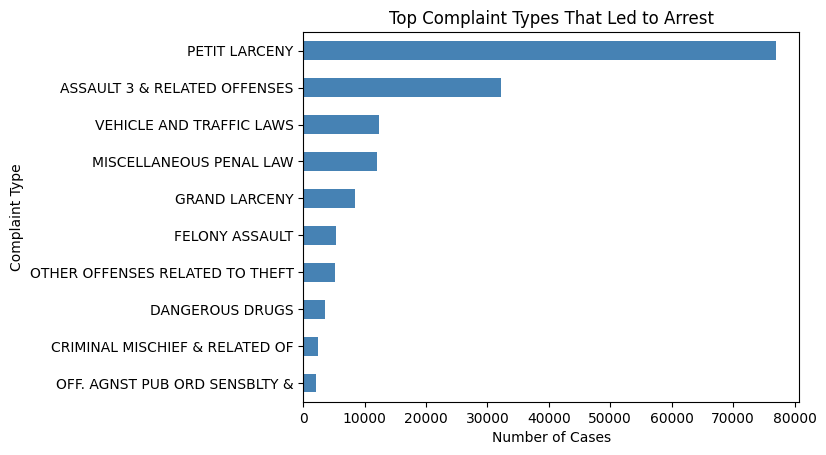

In [66]:
##TopComplaint that let to Arrest (Graph)
top10 = complaints_with_arrest['OFNS_DESC_y'].value_counts().head(10)

top10.plot(kind='barh', color='steelblue')
plt.title('Top Complaint Types That Led to Arrest')
plt.xlabel('Number of Cases')
plt.ylabel('Complaint Type')
plt.gca().invert_yaxis()
plt.show()

In [69]:
###Arrest Complaints by borough
Combined[Combined['ARREST_KEY'].notna()] \
    .groupby('borough') \
    .size() \
    .sort_values(ascending=False)

,0
borough,
BROOKLYN,105839
STATEN ISLAND,48796
QUEENS,12496
(null),57
BRONX,21


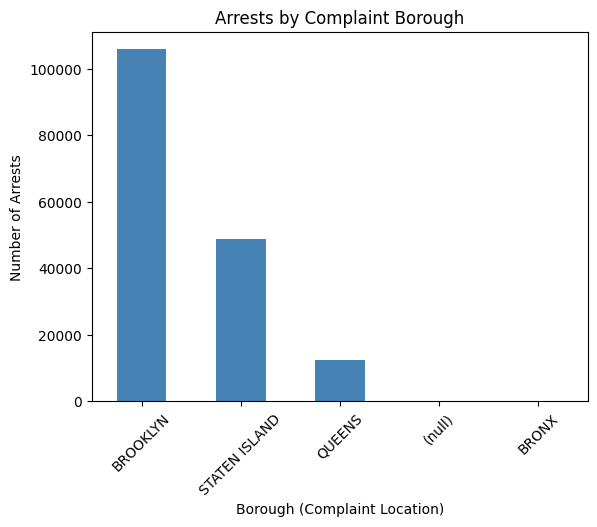

In [70]:
##hich borough generates the most complaints that end in arrest
boro_arrests.plot(kind='bar', legend=False, color='steelblue')

plt.title('Arrests by Complaint Borough')
plt.xlabel('Borough (Complaint Location)')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)

plt.show()

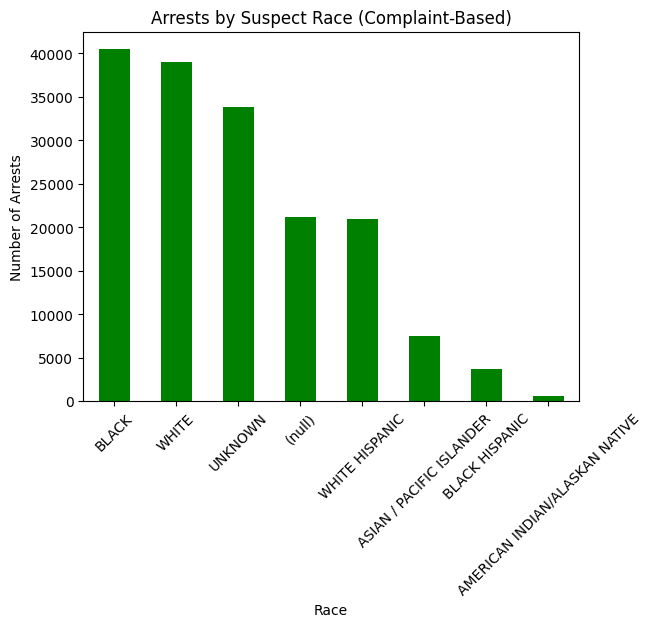

In [78]:
import matplotlib.pyplot as plt

df_arrest = Combined[Combined['ARREST_KEY'].notna()]

race_counts = df_arrest['suspect_race'].value_counts()

race_counts.plot(kind='bar', color='green')

plt.title('Arrests by Suspect Race (Complaint-Based)')
plt.xlabel('Race')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)

plt.show()

In [71]:

import pandas as pd
import statsmodels.api as sm

# outcome
Combined['has_arrest'] = Combined['ARREST_KEY'].notna().astype(int)

# predictors
df = Combined[['has_arrest','borough','suspect_race']].copy()

# fill missing
df = df.fillna('missing')

# group rare categories
for col in ['borough','suspect_race']:
    top = df[col].value_counts().index[:5]
    df[col] = df[col].where(df[col].isin(top), 'Other')

# one-hot encoding
X = pd.get_dummies(df[['borough','suspect_race']], drop_first=True)

# IMPORTANT FIX → force numeric
X = X.astype(float)

y = df['has_arrest'].astype(float)

# add constant
X = sm.add_constant(X)

# logistic regression
model = sm.Logit(y, X).fit(disp=False)

print(model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packa

                           Logit Regression Results                           
Dep. Variable:             has_arrest   No. Observations:               167209
Model:                          Logit   Df Residuals:                   167199
Method:                           MLE   Df Model:                            9
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                     inf
Time:                        20:49:14   Log-Likelihood:            -3.2279e-07
converged:                      False   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          19.3105   2066.785      0.009      0.993   -4031.513    4070.134
borough_BRONX                   8.5073   3.12e+05   2.73e-05      1.000   -6.11e

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/m

There is no statistically evidence that any of the included variables predict arrest outcomes in this model.